# AQA - Air Quality Analysis Pipeline
### European Environment Agency - ERA5 Meteorology - Sentinel-5P

This notebook replicates the AQA pipeline using **EEA** air quality data,
making it applicable to **any European country or bounding box**.

**Pipeline overview**

| Step | Description |
|------|-------------|
| 1 | Configuration: spatial mode, pollutants, date range, dataset |
| 2 | EEA station metadata: filter, clean, map |
| 3 | EEA measurements download (parquet via API) |
| 4 | Build wide dataset + time-window summary |
| 5 | Draw analysis bbox, clip sensors |
| 6 | Build spatial interpolation grid |
| 7 | ERA5 download, merge, unit conversion |
| 8 | ERA5 interpolation on sensor grid |
| 9 | Join EEA + ERA5 (nearest-neighbour) |
| 10 | Sentinel-5P extraction |
| 11 | Rename, visualise, export |

## Libraries & PROJ fix

If you encounter `CRSError: Invalid projection: EPSG:4326`, uncomment the PROJ block.

In [1]:
import os, glob, zipfile, shutil, re, unicodedata, time
import numpy as np
import pandas as pd
import requests
import geopandas as gpd
import xarray as xr
import folium
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path
from datetime import datetime, timedelta
from shapely.geometry import box, Point
from scipy.spatial import distance_matrix
from tqdm import tqdm
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import ee
import geemap
import cdsapi

# PROJ fix (uncomment if CRSError appears)
import pyproj
proj_path = r'C:\Users\Administrador\anaconda3\envs\cmcc_env\Library\share\proj'
os.environ['PROJ_LIB'] = proj_path
pyproj.datadir.set_data_dir(proj_path)
print('PROJ path set:', pyproj.datadir.get_data_dir())

# Google Earth Engine authentication
ee.Authenticate()
ee.Initialize(project='ee-saudisis')  # Replace with your GEE project ID

print('Libraries loaded successfully.')

C:\Users\Administrador\anaconda3\envs\cmcc_env\lib\site-packages\pyproj\network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


PROJ path set: C:\Users\Administrador\anaconda3\envs\cmcc_env\Library\share\proj
Libraries loaded successfully.


## Step 1 - Configuration

Fill in all parameters and click **Save Configuration**.

### EEA Dataset reference

The EEA Download Service provides the following time series:

| Code | Name | Period | Description |
|------|------|--------|-------------|
| **E1a** | Verified data | 2013-2024 | Reported annually by countries by 30 September |
| **E2a** | Up-To-Date (UTD) | 2025 onwards | Transmitted continuously, not yet verified |
| -- | Historical Airbase | 2002-2012 | Pre Air Quality Directive 2008/50/EC (not in this pipeline) |

> **Rule of thumb:** use E1a for past analysis (<= 2024), E2a for near-real-time (2025+).
> `auto` selects E1a for years <= 2023 and E2a for 2024+.

> > **Note:** If you choose **day, month, or year** in _aggregation method_, the downloaded Parquet files will already contain values ​​pre-added by the EEA, so the prev/curr time windows you define in the settings will no longer be practical (there won't be enough temporal resolution to distinguish the Sentinel overpass window). These options are useful if you're using the pipeline only for trend analysis without Sentinel-5P.
> > _Aggregation_ is the method chosen by the user and fetched to the API. This is done as an average/mean calculation. More information is available at: https://dd.eionet.europa.eu/vocabulary/aq/primaryObservation 

### Time windows

Each day is split into two windows bracketing the Sentinel-5P overpass:
- **Previous** -> hours before the overpass (may span midnight).
- **Current** -> the overpass window itself.

Find the sensing time at [Copernicus Browser](https://browser.dataspace.copernicus.eu/):
*Find products for current view* > *Product info* > *Sensing time*.


In [2]:
# Global configuration widget (run once per session).
cfg = {}

# Load country list
stations_path = r'C:\Users\Administrador\Downloads\Thesis\stations_clean.csv'
_tmp = pd.read_csv(stations_path, encoding='latin1', usecols=['Country'],
                   low_memory=False, on_bad_lines='skip')
country_options = sorted(_tmp['Country'].dropna().astype(str).str.strip().unique())

#  Widget style constants 
_S  = {'description_width': '120px'}
_LW = widgets.Layout(width='230px')

#  Spatial mode 
mode_w = widgets.RadioButtons(
    options=[('Country filter', 'country'), ('Bounding box', 'bbox')],
    value='country', description='Spatial mode:', style=_S,
    layout=widgets.Layout(width='270px')
)
country_w = widgets.Dropdown(
    options=country_options,
    value='Italy' if 'Italy' in country_options else country_options[0],
    description='Country:', style=_S, layout=_LW
)

#  Bounding box 
lon_min_w = widgets.FloatText(value=8.9,  description='Min lon:', style=_S, layout=_LW)
lat_min_w = widgets.FloatText(value=45.3, description='Min lat:', style=_S, layout=_LW)
lon_max_w = widgets.FloatText(value=9.6,  description='Max lon:', style=_S, layout=_LW)
lat_max_w = widgets.FloatText(value=45.7, description='Max lat:', style=_S, layout=_LW)

#  Time windows 
prev_start_w = widgets.Text(value='15:01', description='Prev start:', style=_S, layout=_LW)
prev_end_w   = widgets.Text(value='11:59', description='Prev end:',   style=_S, layout=_LW)
curr_start_w = widgets.Text(value='12:00', description='Curr start:', style=_S, layout=_LW)
curr_end_w   = widgets.Text(value='15:00', description='Curr end:',   style=_S, layout=_LW)

#  Pollutant checkboxes 
_poll_options = ['SO2', 'CO', 'NO2', 'NOX as NO2']
_poll_checks  = {p: widgets.Checkbox(
                     value=(p in ['SO2', 'CO', 'NO2']),
                     description=p,
                     style={'description_width': '0px'},
                     layout=widgets.Layout(width='130px')
                 )
                 for p in _poll_options}

#  Date range 
start_date_w = widgets.DatePicker(description='Start date:', style=_S, layout=_LW)
end_date_w   = widgets.DatePicker(description='End date:',   style=_S, layout=_LW)

#  Aggregation and dataset 
agg_w = widgets.Dropdown(
    options=[
        ('Hourly',  'hour'),
        ('Daily',   'day'),
        ('Monthly', 'month'),
        ('Yearly',  'year'),
    ],
    value='hour',
    description='Aggregation:', style=_S, layout=_LW
)
dataset_w = widgets.RadioButtons(
    options=[
        ('auto  (E1a <= 2023 | E2a >= 2024)', 'auto'),
        ('E1a  -- Verified data (2013-2024)',   1),
        ('E2a  -- Up-To-Date / UTD (2025+)',    2),
    ],
    value='auto', description='Dataset:', style=_S,
    layout=widgets.Layout(width='350px')
)
email_w = widgets.Text(
    value='your.email@example.com',
    description='Email:', style=_S, layout=widgets.Layout(width='280px')
)

#  Save button 
btn = widgets.Button(description='Save Configuration', button_style='success',
                         layout=widgets.Layout(width='220px', margin='16px 0 0 0'))
out_cfg = widgets.Output()

def _build_aoi(bbox):
    minx, miny, maxx, maxy = bbox
    aoi = gpd.GeoDataFrame({'id': [1]}, geometry=[box(minx, miny, maxx, maxy)], crs='EPSG:4326')
    return aoi, aoi.to_crs('EPSG:32632')

def _dataset_label(did):
    return {1: 'E1a (verified, 2013-2024)', 2: 'E2a (up-to-date, 2025+)'}.get(did, str(did))

def on_save(_):
    global cfg
    with out_cfg:
        clear_output()
        start_dt = pd.to_datetime(start_date_w.value) if start_date_w.value else None
        end_dt   = pd.to_datetime(end_date_w.value)   if end_date_w.value   else None
        year     = start_dt.year if start_dt is not None else None

        if dataset_w.value == 'auto':
            dataset_id = 1 if (year is None or year <= 2023) else 2  # FIX: E1a for <=2023, E2a for 2024+
        else:
            dataset_id = int(dataset_w.value)

        selected_pollutants = [p for p, cb in _poll_checks.items() if cb.value]
        if not selected_pollutants:
            print('Please select at least one pollutant.')
            return

        if start_dt and end_dt and start_dt > end_dt:
            print('Error: Start date must be before or equal to End date.')
            return

        bbox = ([lon_min_w.value, lat_min_w.value, lon_max_w.value, lat_max_w.value]
                if mode_w.value == 'bbox' else None)

        cfg = {
            'mode':            mode_w.value,
            'country':         country_w.value.strip() if mode_w.value == 'country' else None,
            'bbox':            bbox,
            'pollutants':      selected_pollutants,
            'start_date':      start_dt,
            'end_date':        end_dt,
            'aggregationType': agg_w.value,
            'time_windows': {
                'prev': (prev_start_w.value, prev_end_w.value),
                'curr': (curr_start_w.value, curr_end_w.value),
            },
            'crs_gee':  'EPSG:4326',
            'crs_grid': 'EPSG:32632',
            'sentinel_scale_km': 5.5,
            'api': {
                'apiUrl':          'https://eeadmz1-downloads-api-appservice.azurewebsites.net/',
                'endpoint':        'ParquetFile/async',
                'dataset':         dataset_id,
                'email':           email_w.value.strip(),
                'min_zip_bytes':   10_000,
                'poll_seconds':    20,
                'timeout_seconds': 3600,
            },
            'paths': {
                'thesis_dir':    r'C:\Users\Administrador\Downloads\Thesis',
                'stations_csv':  stations_path,
                'clean_csv':     r'C:\Users\Administrador\Downloads\Thesis\stations_clean.csv',
                'clean_parquet': r'C:\Users\Administrador\Downloads\Thesis\stations_clean.parquet',
                'zip_name':      'EEA_download.zip',
                'extract_dir':   r'C:\Users\Administrador\Downloads\Thesis\EEA_unzipped',
            },
        }

        if cfg['bbox']:
            cfg['aoi'], cfg['aoi_utm'] = _build_aoi(cfg['bbox'])
            cfg['aoi_gee'] = ee.Geometry.Rectangle(cfg['bbox'])
        else:
            cfg['aoi'] = cfg['aoi_utm'] = cfg['aoi_gee'] = None

        cfg['dates'] = pd.date_range(start_dt, end_dt, freq='D') if (start_dt and end_dt) else None

        W = 56
        print('_' * W)
        print('  Configuration saved')
        print('-' * W)
        print(f"  Spatial mode  : {cfg['mode']}")
        if cfg['mode'] == 'country':
            print(f"  Country       : {cfg['country']}")
        else:
            print(f"  Bounding box  : {cfg['bbox']}")
        print(f"  Pollutants    : {', '.join(cfg['pollutants'])}")
        print(f"  Date range    : {cfg['start_date']} -> {cfg['end_date']}")
        print(f"  Aggregation   : {cfg['aggregationType']}")
        print(f"  Dataset       : {_dataset_label(cfg['api']['dataset'])}")
        print(f"  Prev window   : {cfg['time_windows']['prev'][0]} -> {cfg['time_windows']['prev'][1]}")
        print(f"  Curr window   : {cfg['time_windows']['curr'][0]} -> {cfg['time_windows']['curr'][1]}")
        print('_' * W)
        print('  Next: run Step 2 to load station metadata.')

btn.on_click(on_save)

# Layout 
col_spatial = widgets.VBox([
    widgets.HTML('<b>Spatial selection</b>'), mode_w, country_w
], layout=widgets.Layout(padding='0 20px 0 0'))

col_bbox = widgets.VBox([
    widgets.HTML('<b>Bounding box (WGS-84)</b>'),
    lon_min_w, lat_min_w, lon_max_w, lat_max_w
], layout=widgets.Layout(padding='0 20px 0 0'))

col_time = widgets.VBox([
    widgets.HTML('<b>Time windows (HH:MM)</b>'),
    prev_start_w, prev_end_w, curr_start_w, curr_end_w
], layout=widgets.Layout(padding='0 20px 0 0'))

col_right = widgets.VBox([
    widgets.HTML('<b>Pollutants</b>'),
    widgets.HBox(
        list(_poll_checks.values()),
        layout=widgets.Layout(flex_flow='row wrap', width='500px')
    ),
    widgets.HTML('<b>Date range</b>'),
    start_date_w, end_date_w,
    widgets.HTML('<b>Aggregation & Dataset</b>'),
    agg_w, dataset_w,
    widgets.HTML('<b>Email (for EEA API)</b>'),
    email_w,
])

display(widgets.HBox([col_spatial, col_bbox, col_time, col_right]), btn, out_cfg)

Button(button_style='success', description='Save Configuration', layout=Layout(margin='16px 0 0 0', width='220…

Output()

## Step 2 - EEA Station Metadata

Reads `stations.csv` - which has been downloaded from the EEA at https://discomap.eea.europa.eu/App/AQViewer/index.html?fqn=Airquality_Dissem.b2g.measurements - and normalises pollutant names, applies the spatial filter from `cfg`,
and creates a unique `sensor_uid` per physical station.

In [4]:
''' Read and clean the EEA stations metadata CSV.
The file has one row per sensor x pollutant x year.
We normalise pollutant names, filter to selected pollutants,
then deduplicate to one row per unique physical station. '''
W = 56

print('_' * W)
print('  Step 2 - Loading EEA station metadata')
print(f"  Source     : {cfg['paths']['stations_csv']}")
print(f"  Pollutants : {cfg['pollutants']}")
print('_' * W)

meta_path = Path(cfg['paths']['stations_csv'])
df_meta   = pd.read_csv(meta_path, encoding='latin1', low_memory=False, on_bad_lines='skip')
total_raw = len(df_meta)
print(f'\n  Raw rows loaded            : {total_raw:,}')

# Coerce coordinates; drop rows without valid position
df_meta['Longitude'] = pd.to_numeric(df_meta['Longitude'], errors='coerce')
df_meta['Latitude']  = pd.to_numeric(df_meta['Latitude'],  errors='coerce')
df_meta = df_meta.dropna(subset=['Longitude', 'Latitude']).copy()
print(f'  After coordinate validation: {len(df_meta):,}  (dropped {total_raw - len(df_meta):,} without coordinates)')

# Normalise pollutant name variants across different reporting years
df_meta['Air Pollutant'] = df_meta['Air Pollutant'].astype(str).str.strip()
df_meta['Air Pollutant'] = df_meta['Air Pollutant'].replace({
    'NOx as NO2': 'NOX as NO2',
    'NOX AS NO2': 'NOX as NO2',
    'NoX as NO2': 'NOX as NO2',
})

# Filter to the pollutants selected in cfg
before_poll = len(df_meta)
df_meta = df_meta[df_meta['Air Pollutant'].isin(cfg['pollutants'])].copy()
print(f'  After pollutant filter     : {len(df_meta):,}  (dropped {before_poll - len(df_meta):,} for other pollutants)')

cols_clean = [
    'Country', 'B-G Namespace', 'Year', 'Air Quality Network',
    'Air Quality Station EoI Code', 'Air Quality Station Nat Code',
    'Sampling Point Id', 'Air Pollutant', 'Longitude', 'Latitude', 'Measurement Method',
]
df_clean = df_meta[cols_clean].drop_duplicates().copy()
print(f'  After deduplication : {len(df_clean):,} unique sensor x pollutant rows')
print(f'  Countries present : {df_clean["Country"].nunique()}')
print(f'  Pollutants present : {sorted(df_clean["Air Pollutant"].unique())}')

# Apply spatial filter (country or bbox)
print(f'\n  Applying spatial filter - mode = {cfg["mode"]}')
df_clean_sel = df_clean.copy()

if cfg['mode'] == 'country':
    before_sel = len(df_clean_sel)
    df_clean_sel = df_clean_sel[
        df_clean_sel['Country'].astype(str).str.strip() == cfg['country']
    ].copy()
    print(f"  Country '{cfg['country']}': {len(df_clean_sel):,} rows  (from {before_sel:,})")
else:
    minx, miny, maxx, maxy = cfg['bbox']
    before_sel = len(df_clean_sel)
    df_clean_sel = df_clean_sel[
        df_clean_sel['Longitude'].between(minx, maxx) &
        df_clean_sel['Latitude'].between(miny, maxy)
    ].copy()
    print(f'  Bbox filter: {len(df_clean_sel):,} rows  (from {before_sel:,})')

# Build sensor_uid: Country_NatCode_Lon_Lat
df_work = df_clean_sel.copy()
df_work['sensor_uid'] = (
    df_work['Country'].astype(str).str.strip() + '_' +
    df_work['Air Quality Station Nat Code'].astype(str).str.strip() + '_' +
    df_work['Longitude'].round(5).astype(str) + '_' +
    df_work['Latitude'].round(5).astype(str)
)

# Aggregate to unique physical stations
agg_meta = {
    'Country': 'first', 'Year': 'first', 'Air Quality Network': 'first',
    'Air Quality Station EoI Code': 'first', 'Air Quality Station Nat Code': 'first',
    'Sampling Point Id':  lambda x: sorted(set(x.dropna().astype(str))),
    'Air Pollutant':      lambda x: sorted(set(x.dropna())),
    'Longitude': 'first', 'Latitude': 'first',
    'Measurement Method': lambda x: sorted(set(x.dropna())),
}
meta_clean = df_work.groupby('sensor_uid', as_index=False).agg(agg_meta)

# Sensor x pollutant table
agg_sp = {
    'Country': 'first', 'Year': 'first', 'Air Quality Network': 'first',
    'Air Quality Station EoI Code': 'first', 'Air Quality Station Nat Code': 'first',
    'Sampling Point Id': lambda x: sorted(set(x.dropna().astype(str))),
    'Longitude': 'first', 'Latitude': 'first', 'Measurement Method': 'first',
}
sensor_pollutant = df_work.groupby(['sensor_uid', 'Air Pollutant'], as_index=False).agg(agg_sp)

# Save cleaned metadata to disk
df_clean.to_csv(cfg['paths']['clean_csv'], index=False)
df_clean.to_parquet(cfg['paths']['clean_parquet'], index=False)

# Per-pollutant station count
availability = (
    sensor_pollutant.groupby('Air Pollutant')['sensor_uid']
    .nunique().sort_values(ascending=False)
)

selection_label = cfg['country'] if cfg['mode'] == 'country' else 'bbox selection'
print(f'\n{"_" * W}')
print(f'  Station metadata loaded: {selection_label}')
print(f'{"-" * W}')
print(f'  Physical stations (unique sensor_uid)  : {meta_clean["sensor_uid"].nunique():,}')
print(f'  Sensor x pollutant combinations        : {len(sensor_pollutant):,}')
print(f'\n  Stations per pollutant:')
for poll, count in availability.items():
    print(f'    {poll:<20s} : {count:,} stations')
print(f'{"_" * W}')
print('  Next: view the station map, then run Step 3 to download measurements.')
display(sensor_pollutant.head())

________________________________________________________
  Step 2 - Loading EEA station metadata
  Source     : C:\Users\Administrador\Downloads\Thesis\stations_clean.csv
  Pollutants : ['CO']
________________________________________________________

  Raw rows loaded            : 2,274
  After coordinate validation: 2,274  (dropped 0 without coordinates)
  After pollutant filter     : 2,274  (dropped 0 for other pollutants)
  After deduplication : 2,274 unique sensor x pollutant rows
  Countries present : 41
  Pollutants present : ['CO']

  Applying spatial filter - mode = country
  Country 'France': 86 rows  (from 2,274)

________________________________________________________
  Station metadata loaded: France
--------------------------------------------------------
  Physical stations (unique sensor_uid)  : 85
  Sensor x pollutant combinations        : 85

  Stations per pollutant:
    CO                   : 85 stations
________________________________________________________
  Nex

,sensor_uid,Air Pollutant,Country,Year,Air Quality Network,Air Quality Station EoI Code,Air Quality Station Nat Code,Sampling Point Id,Longitude,Latitude,Measurement Method
0,France_FR01005_6.07611_49.32472,CO,France,2024.0,NET-FR075A,FR01005,FR01005,[SPO-FR01005_10],6.07611,49.32472,NDIR
1,France_FR01059_6.08207_49.3374,CO,France,2024.0,NET-FR075A,FR01059,FR01059,[SPO-FR01059_10],6.08207,49.33740,NDIR
2,France_FR01064_6.18122_49.12508,CO,France,2024.0,NET-FR075A,FR01064,FR01064,[SPO-FR01064_10],6.18122,49.12508,NDIR
3,France_FR02008_4.98192_43.40195,CO,France,2024.0,NET-FR070A,FR02008,FR02008,[SPO-FR02008_10],4.98192,43.40195,CRDS
4,France_FR02031_5.21688_43.41569,CO,France,2024.0,NET-FR070A,FR02031,FR02031,[SPO-FR02031_10],5.21688,43.41569,NDIR


### Station map

Interactive map of all stations in the selection. Click a marker to see the EoI code and `sensor_uid`.

In [5]:
# Build a Folium map centered on the selection extent
if cfg['mode'] == 'bbox':
    minx, miny, maxx, maxy = cfg['bbox']
else:
    minx = meta_clean['Longitude'].min()
    miny = meta_clean['Latitude'].min()
    maxx = meta_clean['Longitude'].max()
    maxy = meta_clean['Latitude'].max()

m_stations = folium.Map(
    location=[(miny + maxy) / 2, (minx + maxx) / 2],
    zoom_start=7, tiles='CartoDB positron'
)

for r in meta_clean.itertuples(index=False):
    eoi   = getattr(r, 'Air Quality Station EoI Code', '')
    popup = f"{getattr(r, 'Country', '')} | {eoi} | {r.sensor_uid}"
    folium.CircleMarker(
        location=[r.Latitude, r.Longitude], radius=4,
        popup=popup, color='#2563EB',
        fill=True, fill_color='#2563EB', fill_opacity=0.75,
    ).add_to(m_stations)

print(f'  Map rendered -- {len(meta_clean):,} stations shown.')
m_stations

  Map rendered -- 85 stations shown.


## Step 3 - Download EEA Measurements

Submits an async request to the EEA Download API, polls until the ZIP is ready,
and saves it to disk. The ZIP contains one Parquet file per sensor x pollutant.

In [6]:
''' Submit an async download request to the EEA API.
 The API accepts countries (ISO-2) or bbox, a list of pollutants,
 a dataset (E1a=1 or E2a=2), and a date range.
 It returns a polling URL; we poll until the ZIP is ready. '''

import io
W = 56

apiUrl   = cfg['api']['apiUrl']
endpoint = cfg['api']['endpoint']
zip_path = os.path.join(cfg['paths']['thesis_dir'], cfg['paths']['zip_name'])

# Derive ISO-2 country code from the B-G Namespace field in stations.csv
# FIX: Read with UTF-8 first, fall back to latin1; strip invisible chars; robust iso2 extraction
import re as _re

def _read_stations_for_iso2(path):
    for enc in ('utf-8-sig', 'utf-8', 'latin1', 'cp1252'):
        try:
            df = pd.read_csv(path, encoding=enc,
                             usecols=['Country', 'B-G Namespace'],
                             low_memory=False, on_bad_lines='skip')
            return df
        except Exception:
            continue
    raise IOError(f'Could not read {path} with any known encoding.')

def _clean_str(s):
    """Remove non-ASCII control chars and strip whitespace."""
    return _re.sub(r'[\x00-\x1f\x7f-\x9f]', '', str(s)).strip()

def _extract_iso2(s):
    """Extract 2-letter ISO country code from B-G Namespace value."""
    s = _clean_str(s).upper()
    # Try: first 2 chars if followed by non-alpha or end-of-string
    m = _re.match(r'^([A-Z]{2})(?:[^A-Z]|$)', s)
    if m:
        return m.group(1)
    # Try: first token split by . / _ - \\
    token = _re.split(r'[./_\\\-]', s)[0].strip()
    if _re.fullmatch(r'[A-Z]{2}', token):
        return token
    return None

_tmp2 = _read_stations_for_iso2(cfg['paths']['stations_csv']).dropna()
_tmp2['Country']       = _tmp2['Country'].apply(_clean_str)
_tmp2['B-G Namespace'] = _tmp2['B-G Namespace'].apply(_clean_str)
_tmp2['iso2']          = _tmp2['B-G Namespace'].apply(_extract_iso2)
_tmp2 = _tmp2.dropna(subset=['iso2'])
country_to_iso2 = _tmp2.groupby('Country')['iso2'].agg(lambda x: sorted(set(x))[0]).to_dict()

if cfg['mode'] == 'country':
    # FIX: Clean cfg country name before lookup (removes invisible chars from widget)
    _country_clean = _clean_str(cfg['country'])
    # Try exact match first, then case-insensitive match
    iso2 = country_to_iso2.get(_country_clean)
    if not iso2:
        _map_lower = {k.lower(): v for k, v in country_to_iso2.items()}
        iso2 = _map_lower.get(_country_clean.lower())
    if not iso2:
        print(f"  Available mappings: {list(country_to_iso2.keys())}")
        raise ValueError(f"Cannot derive ISO-2 code for '{cfg['country']}' (cleaned: '{_country_clean}'). "
                         f"Check that the country name in the widget matches exactly.")
    print(f"  Derived ISO-2 code : {iso2} (for '{_country_clean}')")
else:
    iso2 = None

if cfg['start_date'] is None or cfg['end_date'] is None:
    raise ValueError('cfg start_date / end_date are None -- save configuration first.')

# FIX: Warn if dataset/date range combination is likely to return no data
dataset_id    = cfg['api']['dataset']
start_year    = cfg['start_date'].year
dataset_label = {1: 'E1a (verified, 2013-2024)', 2: 'E2a (up-to-date, 2025+)'}.get(dataset_id, str(dataset_id))

if dataset_id == 1 and start_year >= 2025:
    print('\n  ⚠️  WARNING: E1a selezionato ma date range starts in', start_year)
    print('  E1a does NOT contain data for 2025+. Switch to E2a in the configuration widget.')
    raise ValueError('Dataset/date mismatch: switch to E2a for dates >= 2025.')
elif dataset_id == 2 and start_year < 2024:
    print('\n  ⚠️  WARNING: E2a selezionato ma date range starts in', start_year)
    print('  E2a may not contain data before 2024. Switch to E1a for historical data.')
    raise ValueError('Dataset/date mismatch: switch to E1a for dates <= 2023.')

request_body = {
    'countries':       [iso2] if cfg['mode'] == 'country' else [],
    'cities':          [],
    'pollutants':      cfg['pollutants'],
    'dataset':         dataset_id,
    'dateTimeStart':   cfg['start_date'].strftime('%Y-%m-%dT%H:%M:%SZ'),
    'dateTimeEnd':     cfg['end_date'].strftime('%Y-%m-%dT%H:%M:%SZ'),
    'aggregationType': cfg['aggregationType'],
    'email':           cfg['api']['email'],
}

print('_' * W)
print('  Step 3 - EEA Measurements Download')
print('-' * W)
print(f'  Dataset    : {dataset_label}')
print(f"  Pollutants : {', '.join(cfg['pollutants'])}")
print(f"  Period     : {cfg['start_date'].date()} -> {cfg['end_date'].date()}")
print(f"  Mode       : {cfg['mode']}" + (f' ({iso2})' if iso2 else ' (bbox)'))
print('_' * W)

response = requests.post(f'{apiUrl}{endpoint}', json=request_body, timeout=30)
print(f'\n  API response status : {response.status_code}')
if response.status_code != 200:
    raise Exception('Download request failed: ' + response.text)

polling_url = response.text.strip()
print(f'  Polling URL         : {polling_url}')
print(f"  Polling every {cfg['api']['poll_seconds']}s (timeout: {cfg['api']['timeout_seconds']}s) ...")

t_start   = datetime.now()
tiny_hits = 0

while True:
    elapsed = (datetime.now() - t_start).total_seconds()
    if elapsed > cfg['api']['timeout_seconds']:
        raise TimeoutError('Download timed out.')

    try:
        r = requests.get(polling_url, timeout=30)
    except requests.exceptions.Timeout:
        print(f'  [{elapsed:.0f}s] GET timeout, retrying...')
        time.sleep(cfg['api']['poll_seconds'])
        continue

    if r.status_code == 404:
        print(f'  [{elapsed:.0f}s] Not ready yet (404)...')
        time.sleep(cfg['api']['poll_seconds'])
        continue

    if r.status_code != 200:
        print(f'  [{elapsed:.0f}s] Status {r.status_code}, retrying...')
        time.sleep(cfg['api']['poll_seconds'])
        continue

    n_bytes = len(r.content)
    if n_bytes < cfg['api']['min_zip_bytes']:
        tiny_hits += 1
        # FIX: Decode raw response to surface the actual EEA API error message
        try:
            raw_text = r.content.decode('utf-8', errors='replace')
        except Exception:
            raw_text = repr(r.content)
        print(f'  [{elapsed:.0f}s] Payload too small ({n_bytes} bytes), hit {tiny_hits}/6...')
        print(f'  Raw API response  : {raw_text}')

        if tiny_hits >= 6:
            try:
                err_json = r.json()
                print(f'  API error message : {err_json}')
            except Exception:
                pass
            try:
                with zipfile.ZipFile(io.BytesIO(r.content)) as z:
                    print(f'  ZIP contents: {z.namelist()}')
                    for name in z.namelist():
                        content = z.read(name)
                        print(f'  File {name!r} ({len(content)} bytes): {content[:500].decode(errors="replace")}')
            except Exception as _ze:
                print(f'  Could not open as ZIP: {_ze}')
            print('\n  ❌ POSSIBLE CAUSES:')
            print('  1. Dataset/date mismatch: E1a only covers 2013-2024, E2a covers 2024+.')
            print('  2. No data for this pollutant/country/period combination.')
            print('  3. EEA API error — see raw response above.')
            print('  → Fix the dataset and date range in Step 1 and re-run.')
            raise RuntimeError('Download returned a very small payload. See diagnostics above.')
        time.sleep(cfg['api']['poll_seconds'])
        continue

    with open(zip_path, 'wb') as f:
        f.write(r.content)
    print(f'\n  Download complete in {elapsed:.0f}s')
    print(f'  File size  : {n_bytes / 1024:.1f} KB')
    print(f'  Saved to   : {zip_path}')
    print('  Next: run the unzip cell.')
    break

  Derived ISO-2 code : FR (for 'France')
________________________________________________________
  Step 3 - EEA Measurements Download
--------------------------------------------------------
  Dataset    : E2a (up-to-date, 2025+)
  Pollutants : CO
  Period     : 2024-01-01 -> 2024-01-06
  Mode       : country (FR)
________________________________________________________

  API response status : 200
  Polling URL         : https://eeadmz1batchservice02.blob.core.windows.net/downloads/4e6ab151-0703-4f78-840f-738c86bac724/ParquetFile.zip
  Polling every 20s (timeout: 3600s) ...
  [0s] Not ready yet (404)...

  Download complete in 20s
  File size  : 37.6 KB
  Saved to   : C:\Users\Administrador\Downloads\Thesis\EEA_download.zip
  Next: run the unzip cell.


## Step 4a - Unzip & List Parquet Files

In [7]:
# Extract the downloaded ZIP and collect all Parquet file paths.
W = 56
extract_dir = cfg['paths']['extract_dir']

if os.path.exists(extract_dir):
    shutil.rmtree(extract_dir)
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_dir)

parquet_files = []
for root, _, files in os.walk(extract_dir):
    for f in files:
        if f.lower().endswith('.parquet'):
            parquet_files.append(os.path.join(root, f))

print('_' * W)
print(f'  Unzip complete')
print(f'  Parquet files found : {len(parquet_files):,}')
if parquet_files:
    print(f'  First file          : {os.path.basename(parquet_files[0])}')
print('_' * W)
print('  Next: run Step 4b to build the wide dataset.')

________________________________________________________
  Unzip complete
  Parquet files found : 18
  First file          : SPO-FR02008_10.parquet
________________________________________________________
  Next: run Step 4b to build the wide dataset.


## Step 4b - Build Wide Dataset

Reads all Parquet files, matches them to station metadata via Sampling Point Id,
and pivots to a wide format with one column per pollutant.

In [8]:
''' Build the wide measurement table from all downloaded Parquet files.
 1. Normalise the Sampling Point Id key to match metadata.
 2. Merge to attach coordinates and station codes.
 3. Pivot to wide: one column per pollutant (values) + one per unit.'''

W = 56

def spo_key_simple(s):
    # Strip country prefix and normalise to uppercase key
    if pd.isna(s):
        return np.nan
    s = str(s).strip().upper()
    s = re.sub(r'^[A-Z]{2}\s*/\s*', '', s)
    return s

meta_sp = df_clean_sel.rename(columns={'Sampling Point Id': 'Sampling Point Id_meta'}).copy()
meta_sp['spo_key'] = meta_sp['Sampling Point Id_meta'].apply(spo_key_simple)
meta_sp = meta_sp.drop_duplicates('spo_key')

base_parts = []
skipped    = 0

print(f'  Processing {len(parquet_files):,} Parquet files...')
for i, meas_file in enumerate(tqdm(parquet_files, desc='  Reading parquets', unit='file'), start=1):
    d = pd.read_parquet(meas_file)
    if len(d) == 0:
        skipped += 1
        continue

    d['spo_key'] = d['Samplingpoint'].apply(spo_key_simple)
    dm = d.merge(meta_sp, on='spo_key', how='left')

    dm['Start'] = pd.to_datetime(dm['Start'], errors='coerce', utc=True)
    dm['Value'] = pd.to_numeric(dm['Value'], errors='coerce')

    part_cols = [
        'Air Quality Station EoI Code', 'Air Quality Station Nat Code',
        'Longitude', 'Latitude', 'Start', 'Air Pollutant', 'Value', 'Unit'
    ]
    if 'sensor_uid' in dm.columns:
        part_cols.insert(0, 'sensor_uid')

    part = dm.dropna(subset=['Longitude','Latitude','Start','Air Pollutant','Value'])[part_cols].copy()
    base_parts.append(part)

base_all_full = pd.concat(base_parts, ignore_index=True)

index_cols = ['Longitude','Latitude','Start','Air Quality Station EoI Code','Air Quality Station Nat Code']
if 'sensor_uid' in base_all_full.columns:
    index_cols = ['sensor_uid'] + index_cols

# Pivot values
wide_all_full = (
    base_all_full
    .pivot_table(index=index_cols, columns='Air Pollutant', values='Value', aggfunc='first')
    .reset_index()
)
wide_all_full.columns.name = None

# Pivot units
wide_units_full = (
    base_all_full
    .pivot_table(index=index_cols, columns='Air Pollutant', values='Unit', aggfunc='first')
    .reset_index()
)
wide_units_full.columns.name = None
unit_cols = [c for c in wide_units_full.columns if c not in index_cols]
wide_units_full = wide_units_full.rename(columns={c: f'{c}_unit' for c in unit_cols})

wide_all_full_with_units = wide_all_full.merge(wide_units_full, on=index_cols, how='left')

# Save outputs
out_dir   = cfg['paths']['thesis_dir']
wide_path = os.path.join(out_dir, 'wide_output.parquet')
wide_csv  = os.path.join(out_dir, 'wide_output.csv')
wide_all_full_with_units.to_parquet(wide_path, index=False)  # FIX: save with unit columns
wide_all_full_with_units.to_csv(wide_csv, index=False)

print(f'\n{"_" * W}')
print(f'  Wide dataset built')
print(f'{"-" * W}')
print(f'  Parquet files processed  : {len(parquet_files) - skipped:,}  (skipped empty: {skipped})')
print(f'  Total measurement rows   : {len(base_all_full):,}')
print(f'  Wide table shape         : {wide_all_full_with_units.shape[0]:,} rows x {wide_all_full_with_units.shape[1]} columns')
print(f'  Pollutants found         : {sorted(base_all_full["Air Pollutant"].unique())}')
print(f'  Saved (parquet)          : {wide_path}')
print(f'  Saved (csv)              : {wide_csv}')
print(f'{"_" * W}')
print('  Next: run Step 4c to build the time-window summary.')
display(wide_all_full_with_units.head())

  Processing 18 Parquet files...


  Reading parquets: 100%|████████████████████████████████████████████████████████████| 18/18 [00:00<00:00, 25.47file/s]


________________________________________________________
  Wide dataset built
--------------------------------------------------------
  Parquet files processed  : 18  (skipped empty: 0)
  Total measurement rows   : 2,156
  Wide table shape         : 2,156 rows x 7 columns
  Pollutants found         : ['CO']
  Saved (parquet)          : C:\Users\Administrador\Downloads\Thesis\wide_output.parquet
  Saved (csv)              : C:\Users\Administrador\Downloads\Thesis\wide_output.csv
________________________________________________________
  Next: run Step 4c to build the time-window summary.


,Longitude,Latitude,Start,Air Quality Station EoI Code,Air Quality Station Nat Code,CO,CO_unit
0,-52.32093,4.93785,2024-01-01 04:00:00+00:00,FR40008,FR40008,-999.0,mg.m-3
1,-52.32093,4.93785,2024-01-01 05:00:00+00:00,FR40008,FR40008,-999.0,mg.m-3
2,-52.32093,4.93785,2024-01-01 06:00:00+00:00,FR40008,FR40008,-999.0,mg.m-3
3,-52.32093,4.93785,2024-01-01 07:00:00+00:00,FR40008,FR40008,-999.0,mg.m-3
4,-52.32093,4.93785,2024-01-01 08:00:00+00:00,FR40008,FR40008,-999.0,mg.m-3


## Step 4c - Time-Window Summary

Classifies each measurement into `previous` or `current` window and
computes per-station daily means

In [9]:
''' Build the per-station per-day summary (prev_mean, curr_mean). '''

W = 56

pollutant_selected = cfg['pollutants'][0]
print(f'  Pollutant selected for summary : {pollutant_selected}')

eea = wide_all_full_with_units.copy()

if pollutant_selected not in eea.columns:
    available = [c for c in eea.columns if c in ['SO2','CO','NO2','NOX as NO2']]
    raise ValueError(f"Pollutant '{pollutant_selected}' not found. Available: {available}")

# FIX: Replace EEA sentinel value -9999 with NaN before any calculation
eea[pollutant_selected] = eea[pollutant_selected].replace(-9999, np.nan)
eea[pollutant_selected] = pd.to_numeric(eea[pollutant_selected], errors='coerce')
before_drop = len(eea)
eea = eea.dropna(subset=[pollutant_selected]).copy()
print(f'  Rows after dropping NaN [{pollutant_selected}] : {len(eea):,}  (removed {before_drop - len(eea):,})')

# Build long merged table matching ARPA schema
merged = pd.DataFrame({
    'idsensore': eea['Air Quality Station EoI Code'].astype(str),
    'pollutant': pollutant_selected,
    'data':      pd.to_datetime(eea['Start'], utc=True, errors='coerce'),
    'value':     pd.to_numeric(eea[pollutant_selected], errors='coerce'),
    'lat':       pd.to_numeric(eea['Latitude'],  errors='coerce'),
    'lng':       pd.to_numeric(eea['Longitude'], errors='coerce'),
    'provincia': 'EEA',
})
merged = merged.dropna(subset=['data','value','lat','lng']).copy()
merged['date'] = merged['data'].dt.date

def classify_period(ts, date_analysis):
    # Classify a timestamp into 'previous' or 'current' window.
    # NOTE: cfg time_windows (e.g. '12:00') are interpreted as UTC.
    # If your overpass time is local (e.g. Italy UTC+1/+2), subtract
    # the offset before entering it in the configuration widget.
    # All comparisons are in UTC to avoid tz-naive vs tz-aware errors.
    if pd.isna(ts):
        return None
    ts = pd.to_datetime(ts, utc=True)
    prev_s, prev_e = cfg['time_windows']['prev']
    curr_s, curr_e = cfg['time_windows']['curr']
    date_dt  = pd.to_datetime(date_analysis).date()
    prev_day = (pd.to_datetime(date_dt) - pd.Timedelta(days=1)).date()
    curr_start = pd.to_datetime(f'{date_dt} {curr_s}', utc=True)
    curr_end   = pd.to_datetime(f'{date_dt} {curr_e}', utc=True)
    prev_start = pd.to_datetime(f'{prev_day} {prev_s}', utc=True)
    prev_end   = pd.to_datetime(f'{date_dt} {prev_e}', utc=True)
    if curr_start <= ts <= curr_end:
        return 'current'
    elif prev_start <= ts <= prev_end:
        return 'previous'
    return None

all_summaries = []
date_range    = pd.date_range(cfg['start_date'], cfg['end_date'], freq='D')

print(f'\n  Computing daily summaries for {len(date_range)} day(s)...')
for date_analysis in tqdm(date_range, desc='  Summarising', unit='day'):
    prev_day = date_analysis - pd.Timedelta(days=1)
    subset   = merged[merged['data'].dt.date.isin([prev_day.date(), date_analysis.date()])].copy()
    if subset.empty:
        continue
    subset['period'] = subset['data'].apply(lambda ts: classify_period(ts, date_analysis.date()))
    subset = subset.dropna(subset=['period'])
    if subset.empty:
        continue
    day_summary = (
        subset
        .groupby(['idsensore','lat','lng','provincia','period'])['value']
        .mean().reset_index()
        .pivot(index=['idsensore','lat','lng','provincia'], columns='period', values='value')
        .reset_index()
        .rename(columns={'current': 'curr_mean', 'previous': 'prev_mean'})
    )
    day_summary['pollutant'] = pollutant_selected
    day_summary['date']      = date_analysis.date()
    all_summaries.append(day_summary)

if not all_summaries:
    raise RuntimeError('No summaries generated -- check date range and time windows.')

summary = pd.concat(all_summaries, ignore_index=True)
for col in ['curr_mean', 'prev_mean']:
    if col not in summary.columns:
        summary[col] = np.nan

# Build GeoDataFrame in EPSG:32632 (same CRS as original AQA pipeline)
summary_gdf = gpd.GeoDataFrame(
    summary.copy(),
    geometry=gpd.points_from_xy(summary['lng'], summary['lat']),
    crs='EPSG:4326'
).to_crs('EPSG:32632')

print(f'\n{"_" * W}')
print(f'  Time-window summary complete')
print(f'{"-" * W}')
print(f'  Days processed             : {len(all_summaries)}')
print(f'  Total summary rows         : {len(summary):,}')
print(f'  Unique stations in summary : {summary["idsensore"].nunique():,}')
print(f'  Pollutant                  : {pollutant_selected}')
print(f'  summary_gdf shape          : {summary_gdf.shape}')
print(f'{"_" * W}')
print('  Next: draw your analysis bbox on the map (Step 5).')
display(summary.head())

  Pollutant selected for summary : CO
  Rows after dropping NaN [CO] : 2,156  (removed 0)

  Computing daily summaries for 6 day(s)...


  Summarising: 100%|████████████████████████████████████████████████████████████████████| 6/6 [00:07<00:00,  1.19s/day]


________________________________________________________
  Time-window summary complete
--------------------------------------------------------
  Days processed             : 6
  Total summary rows         : 108
  Unique stations in summary : 18
  Pollutant                  : CO
  summary_gdf shape          : (108, 9)
________________________________________________________
  Next: draw your analysis bbox on the map (Step 5).


period,idsensore,lat,lng,provincia,curr_mean,prev_mean,pollutant,date
0,FR02008,43.40195,4.98192,EEA,0.44750,-82.935667,CO,2024-01-01
1,FR03043,43.30529,5.39472,EEA,0.26350,0.262500,CO,2024-01-01
2,FR04055,48.86212,2.34462,EEA,0.17800,0.163833,CO,2024-01-01
3,FR05083,49.50273,0.23249,EEA,0.17225,0.165333,CO,2024-01-01
4,FR05084,49.49333,0.57185,EEA,0.20550,0.195583,CO,2024-01-01


## Step 5 - Draw Analysis Bounding Box

Use the **rectangle tool** on the map below, then click **Save bbox to cfg**.
The bbox will clip the sensor set and define the ERA5 download area.

In [13]:
# Center the interactive map on the sensor coverage
s = summary_gdf.to_crs('EPSG:4326').copy()
center_lat = float(s.geometry.y.mean())
center_lon = float(s.geometry.x.mean())

m_draw = geemap.Map(center=(center_lat, center_lon), zoom=7)
try:
    m_draw.add_points_from_xy(s, x='lng', y='lat')
except Exception:
    pass

m_draw.add_draw_control()
dc = m_draw.draw_control
dc.rectangle    = {'shapeOptions': {'fillOpacity': 0.1}}
dc.polygon = dc.polyline = dc.circle = dc.circlemarker = dc.marker = {}

_last_bbox  = {'bbox': None}
out_draw    = widgets.Output()
btn_draw    = widgets.Button(description='Save bbox to cfg', button_style='success',
                             layout=widgets.Layout(width='200px', margin='8px 0 0 0'))

def _on_draw(target, action, geo_json):
    # Capture the drawn rectangle as [minx, miny, maxx, maxy]
    geom = geo_json.get('geometry', {})
    if geom.get('type') != 'Polygon':
        return
    ring = geom.get('coordinates', [[]])[0]
    lons = [p[0] for p in ring]
    lats = [p[1] for p in ring]
    _last_bbox['bbox'] = [min(lons), min(lats), max(lons), max(lats)]
    with out_draw:
        clear_output()
        print(f"  Bbox captured (not yet saved) : {_last_bbox['bbox']}")
        print('  Click Save bbox to cfg to confirm.')

dc.on_draw(_on_draw)

def _save_bbox(_):
    with out_draw:
        if _last_bbox['bbox'] is None:
            print('  Draw a rectangle first -- no bbox captured yet.')
            return
        cfg['bbox']    = _last_bbox['bbox']
        cfg['mode']    = 'bbox'
        cfg['aoi_gee'] = ee.Geometry.Rectangle(cfg['bbox'])
        print(f"  cfg bbox saved : {cfg['bbox']}")
        print('  Next: run the clip cell.')

btn_draw.on_click(_save_bbox)
display(m_draw, btn_draw, out_draw)

Map(center=[37.68393222221932, 4.970226111107935], controls=(WidgetControl(options=['position', 'transparent_b…

Button(button_style='success', description='Save bbox to cfg', layout=Layout(margin='8px 0 0 0', width='200px'…

Output()

## Step 5b - Clip Sensors to Bbox

In [14]:
''' Clip summary_gdf to the drawn bbox.
 Reports how many stations were retained vs removed. '''
W = 56

if not cfg.get('bbox'):
    raise ValueError("cfg['bbox'] is missing - draw and save a rectangle first (Step 5).")

minx, miny, maxx, maxy = cfg['bbox']
s_wgs = summary_gdf.to_crs('EPSG:4326').copy()
total_before    = len(s_wgs)
stations_before = s_wgs['idsensore'].nunique()

mask = (
    (s_wgs.geometry.x >= minx) & (s_wgs.geometry.x <= maxx) &
    (s_wgs.geometry.y >= miny) & (s_wgs.geometry.y <= maxy)
)
summary_gdf_clip_wgs = s_wgs.loc[mask].copy()
summary_gdf_clip     = summary_gdf_clip_wgs.to_crs('EPSG:32632')
stations_after = summary_gdf_clip_wgs['idsensore'].nunique()

print('_' * W)
print('  Bbox clip applied')
print('-' * W)
print(f'  Bbox                    : {cfg["bbox"]}')
print(f'  Rows before clip        : {total_before:,}')
print(f'  Rows after clip         : {len(summary_gdf_clip_wgs):,}  (removed {total_before - len(summary_gdf_clip_wgs):,})')
print(f'  Unique stations before  : {stations_before:,}')
print(f'  Unique stations after   : {stations_after:,}  (removed {stations_before - stations_after:,})')
print('_' * W)
print('  Next: build the spatial interpolation grid (Step 6).')
display(summary_gdf_clip_wgs.head())

________________________________________________________
  Bbox clip applied
--------------------------------------------------------
  Bbox                    : [0.196361, 49.2274, 1.031096, 49.719978]
  Rows before clip        : 108
  Rows after clip         : 12  (removed 96)
  Unique stations before  : 18
  Unique stations after   : 2  (removed 16)
________________________________________________________
  Next: build the spatial interpolation grid (Step 6).


period,idsensore,lat,lng,provincia,curr_mean,prev_mean,pollutant,date,geometry
3,FR05083,49.50273,0.23249,EEA,0.17225,0.165333,CO,2024-01-01,POINT (0.23249 49.50273)
4,FR05084,49.49333,0.57185,EEA,0.20550,0.195583,CO,2024-01-01,POINT (0.57185 49.49333)
21,FR05083,49.50273,0.23249,EEA,0.13325,0.136750,CO,2024-01-02,POINT (0.23249 49.50273)
22,FR05084,49.49333,0.57185,EEA,0.16675,0.176800,CO,2024-01-02,POINT (0.57185 49.49333)
39,FR05083,49.50273,0.23249,EEA,0.14175,0.137000,CO,2024-01-03,POINT (0.23249 49.50273)


## Step 6 - Build Spatial Interpolation Grid

Constructs a regular grid over the clipped sensor domain.
Resolution = 90% of the minimum inter-sensor distance.

In [15]:
''' Build a regular point grid over the clipped sensor domain.
 Extent is derived from actual sensor coordinates, NOT cfg['bbox'] directly,
 to avoid empty-area issues when the drawn bbox is larger than the sensor coverage. '''

W = 56

sensors = summary_gdf_clip_wgs.drop_duplicates(subset=['idsensore']).copy()

if len(sensors) < 2:
    raise ValueError(
        f'At least 2 sensors required, but only {len(sensors)} found in the clipped area.'
    )

# Tight bbox from actual sensor coordinates
sensor_minx = float(sensors.geometry.x.min())
sensor_miny = float(sensors.geometry.y.min())
sensor_maxx = float(sensors.geometry.x.max())
sensor_maxy = float(sensors.geometry.y.max())
sensor_bbox = [sensor_minx, sensor_miny, sensor_maxx, sensor_maxy]

# Grid resolution: 90% of minimum inter-sensor distance
coords   = np.column_stack([sensors.geometry.x, sensors.geometry.y])
dist_mat = distance_matrix(coords, coords)
dist_mat[dist_mat == 0] = np.nan
min_dist_deg = float(np.nanmin(dist_mat))
res = min_dist_deg * 0.9

xs = np.arange(sensor_minx, sensor_maxx + res, res)
ys = np.arange(sensor_miny, sensor_maxy + res, res)
grid_points = [Point(x, y) for x in xs for y in ys]

grid_gdf = gpd.GeoDataFrame(
    {'grid_id': range(len(grid_points))},
    geometry=grid_points, crs='EPSG:4326'
)

# Prepare grid_wgs84 for ERA5 interpolation
grid_wgs84 = grid_gdf.to_crs('EPSG:4326').copy()
grid_wgs84['lat'] = grid_wgs84.geometry.y
grid_wgs84['lon'] = grid_wgs84.geometry.x

print('_' * W)
print('  Spatial grid built')
print('-' * W)
print(f'  Clipped sensors used     : {len(sensors):,}')
print(f'  Sensor bbox (WGS-84)     : {sensor_bbox}')
print(f"  cfg bbox                 : {cfg.get('bbox')}")
print(f'  Min inter-sensor dist    : {min_dist_deg:.6f} deg')
print(f'  Grid resolution          : {res:.6f} deg  (= 90% of min dist)')
print(f'  Grid dimensions          : {len(xs)} x {len(ys)} = {len(grid_gdf):,} points')
print('_' * W)
print('  Next: download ERA5 data (Step 7).')
display(grid_wgs84[['grid_id','lat','lon']].head())

________________________________________________________
  Spatial grid built
--------------------------------------------------------
  Clipped sensors used     : 2
  Sensor bbox (WGS-84)     : [0.23249000000000325, 49.49333, 0.571849999999996, 49.502729999999985]
  cfg bbox                 : [0.196361, 49.2274, 1.031096, 49.719978]
  Min inter-sensor dist    : 0.339490 deg
  Grid resolution          : 0.305541 deg  (= 90% of min dist)
  Grid dimensions          : 3 x 2 = 6 points
________________________________________________________
  Next: download ERA5 data (Step 7).


,grid_id,lat,lon
0,0,49.493330,0.232490
1,1,49.798871,0.232490
2,2,49.493330,0.538031
3,3,49.798871,0.538031
4,4,49.493330,0.843572


## Step 7 - ERA5 Download

Downloads ERA5 reanalysis variables via the CDS API.
A **0.5 deg buffer** is added to the sensor bbox to guarantee ERA5 grid point coverage
(ERA5 native resolution is 0.25 deg).

In [16]:
''' Download ERA5 single-level variables from the Copernicus CDS.
 A 0.5 deg buffer ensures the area always contains ERA5 native grid points. '''

W = 56

# Close any open xarray datasets to release Windows file locks before deleting
# FIX: Guard against NameError on first run
for _var in ['datasets', 'merged_xr', 'ds_xr']:
    try:
        obj = eval(_var)
        if hasattr(obj, '__iter__') and not hasattr(obj, 'close'):
            for ds in obj: ds.close()
        else:
            obj.close()
    except Exception:
        pass

# Delete previous downloads to avoid stale data
for f in glob.glob('era5_data/*.nc'):
    try:
        os.remove(f)
    except PermissionError as e:
        print(f'  Could not delete {os.path.basename(f)}: {e}')
        print('  Restart the kernel and re-run from this cell.')

os.makedirs('era5_data', exist_ok=True)

start_date_era5 = pd.to_datetime(cfg['start_date']).date()
end_date_era5   = pd.to_datetime(cfg['end_date']).date()

minx, miny, maxx, maxy = cfg['bbox']
buffer = 0.5
area = [
    round(maxy + buffer, 4),  # north
    round(minx - buffer, 4),  # west
    round(miny - buffer, 4),  # south
    round(maxx + buffer, 4),  # east
]

variables = [
    '2m_temperature', 'surface_net_solar_radiation', 'surface_net_thermal_radiation',
    'surface_pressure', 'total_precipitation',
    '10m_u_component_of_wind', '10m_v_component_of_wind', 'boundary_layer_height',
]

print('_' * W)
print('  Step 7 -- ERA5 Download')
print('-' * W)
print(f'  Sensor bbox      : {[minx, miny, maxx, maxy]}')
print(f'  ERA5 area (+{buffer} deg): {area}  [N, W, S, E]')
print(f'  Period           : {start_date_era5} -> {end_date_era5}')
print(f'  Variables        : {len(variables)}')
print('  This may take several minutes per variable...')
print('_' * W)

client = cdsapi.Client()

for var in tqdm(variables, desc='  Downloading ERA5', unit='var'):
    out_file = f'era5_data/{var}_{start_date_era5}_{end_date_era5}.nc'
    if os.path.exists(out_file):
        tqdm.write(f'  Exists, skipping: {var}')
        continue
    client.retrieve(
        'reanalysis-era5-single-levels',
        {
            'product_type': 'reanalysis', 'format': 'netcdf',
            'variable': [var],
            'date': f'{start_date_era5}/{end_date_era5}',
            'time': [f'{h:02d}:00' for h in range(24)],
            'area': area,
        },
        out_file,
    )
    tqdm.write(f'  Saved: {out_file}')

print(f'\n  ERA5 download complete. Run Step 7b to merge and convert units.')

________________________________________________________
  Step 7 -- ERA5 Download
--------------------------------------------------------
  Sensor bbox      : [0.196361, 49.2274, 1.031096, 49.719978]
  ERA5 area (+0.5 deg): [50.22, -0.3036, 48.7274, 1.5311]  [N, W, S, E]
  Period           : 2024-01-01 -> 2024-01-06
  Variables        : 8
  This may take several minutes per variable...
________________________________________________________


2026-03-24 20:58:32,747 INFO Request ID is 3b492bff-8581-41bd-8c7e-8254300e135d
2026-03-24 20:58:32,848 INFO status has been updated to accepted
2026-03-24 20:58:41,434 INFO status has been updated to running
2026-03-24 20:59:05,720 INFO status has been updated to successful


7988610a576ad03d13cf285944b71e60.nc:   0%|          | 0.00/43.8k [00:00<?, ?B/s]

  Saved: era5_data/2m_temperature_2024-01-01_2024-01-06.nc


2026-03-24 20:59:06,949 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2026-03-24 20:59:06,950 INFO Request ID is 0a7653af-a747-4c1f-8f84-866c3ce7e586
2026-03-24 20:59:06,977 INFO status has been updated to accepted
2026-03-24 20:59:20,554 INFO status has been updated to running
2026-03-24 20:59:39,719 INFO status has been updated to successful


...

52121023519a553e7b4f6a670aa53a27.nc:   0%|          | 0.00/47.2k [00:00<?, ?B/s]

  Saved: era5_data/10m_v_component_of_wind_2024-01-01_2024-01-06.nc


2026-03-24 21:02:10,558 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2026-03-24 21:02:10,559 INFO Request ID is d486e6a9-2f83-47f9-b18f-05b9cf595a6b
2026-03-24 21:02:10,658 INFO status has been updated to accepted
2026-03-24 21:02:19,056 INFO status has been updated to running
2026-03-24 21:02:43,549 INFO status has been updated to successful


403916255fb41a45a22bd759cab8b760.nc:   0%|          | 0.00/45.9k [00:00<?, ?B/s]

  Saved: era5_data/boundary_layer_height_2024-01-01_2024-01-06.nc

  ERA5 download complete. Run Step 7b to merge and convert units.


## Step 7b - Merge ERA5 Files & Convert Units

In [17]:
''' Merge all .nc files and apply unit conversions.
# t2m [K] -> t2m_c [C], sp [Pa] -> sp_hpa [hPa],
# ssr/str [J] -> kJ, blh [m] -> km, u10/v10 -> wind_speed [m/s] '''

W = 56

folder = 'era5_data'
files  = sorted(glob.glob(os.path.join(folder, '*.nc')))
if not files:
    raise FileNotFoundError('No .nc files found in era5_data/ - run the download cell first.')

datasets  = [xr.open_dataset(f) for f in files]
merged_xr = xr.merge(datasets)
ds_xr     = merged_xr.copy()
conversions_done = []

if 't2m'  in ds_xr: ds_xr['t2m_c']      = ds_xr['t2m'] - 273.15;          conversions_done.append('t2m [K] -> t2m_c [C]')
if 'sp'   in ds_xr: ds_xr['sp_hpa']     = ds_xr['sp'] / 100.0;             conversions_done.append('sp [Pa] -> sp_hpa [hPa]')
if 'ssr'  in ds_xr: ds_xr['ssr_kJ']     = ds_xr['ssr'] / 1000.0;           conversions_done.append('ssr [J] -> ssr_kJ [kJ/m2]')
if 'str'  in ds_xr: ds_xr['str_kJ']     = ds_xr['str'] / 1000.0;           conversions_done.append('str [J] -> str_kJ [kJ/m2]')
if 'blh'  in ds_xr: ds_xr['blh_km']     = ds_xr['blh'] / 1000.0;           conversions_done.append('blh [m] -> blh_km [km]')
if 'u10' in ds_xr and 'v10' in ds_xr:
    ds_xr['wind_speed'] = np.sqrt(ds_xr['u10']**2 + ds_xr['v10']**2)
    conversions_done.append('u10, v10 -> wind_speed [m/s]')

vars_era5 = [v for v in ['t2m_c','sp_hpa','wind_speed','blh_km','tp','ssr_kJ','str_kJ']
             if v in ds_xr.data_vars]

print('_' * W)
print('  ERA5 files merged & units converted')
print('-' * W)
print(f'  Files merged        : {len(files)}')
print(f'  Raw variables       : {list(merged_xr.data_vars)}')
print(f'  Unit conversions    :')
for c in conversions_done:
    print(f'    {c}')
print(f'  Variables for interp: {vars_era5}')
print('_' * W)

________________________________________________________
  ERA5 files merged & units converted
--------------------------------------------------------
  Files merged        : 8
  Raw variables       : ['u10', 'v10', 't2m', 'blh', 'ssr', 'str', 'sp', 'tp']
  Unit conversions    :
    t2m [K] -> t2m_c [C]
    sp [Pa] -> sp_hpa [hPa]
    ssr [J] -> ssr_kJ [kJ/m2]
    str [J] -> str_kJ [kJ/m2]
    blh [m] -> blh_km [km]
    u10, v10 -> wind_speed [m/s]
  Variables for interp: ['t2m_c', 'sp_hpa', 'wind_speed', 'blh_km', 'tp', 'ssr_kJ', 'str_kJ']
________________________________________________________


## Step 8 - Interpolate ERA5 on Sensor Grid

In [18]:
# Bilinearly interpolate ERA5 variables onto the sensor grid for each timestep.
W = 56
results = []
time_steps = ds_xr['valid_time'].values

print(f'  Interpolating {len(vars_era5)} ERA5 vars over {len(time_steps):,} timesteps x {len(grid_wgs84):,} grid points...')

for t in tqdm(time_steps, desc='  ERA5 interpolation', unit='timestep'):
    ds_hour = ds_xr.sel(valid_time=t)
    interp  = ds_hour[vars_era5].interp(
        latitude=(  'points', grid_wgs84['lat']),
        longitude=( 'points', grid_wgs84['lon'])
    )
    interp_df = interp.to_dataframe().reset_index(drop=True)
    interp_df['valid_time'] = pd.to_datetime(t)
    interp_df['grid_id']    = grid_wgs84['grid_id'].values
    interp_df['lat']        = grid_wgs84['lat'].values
    interp_df['lon']        = grid_wgs84['lon'].values
    results.append(interp_df)

era5_on_grid = pd.concat(results, ignore_index=True)
nn_frac = era5_on_grid['t2m_c'].notna().mean() if 't2m_c' in era5_on_grid else None

print(f'\n{"_" * W}')
print(f'  ERA5 interpolation complete')
print(f'{"-" * W}')
print(f'  Output shape            : {era5_on_grid.shape[0]:,} rows x {era5_on_grid.shape[1]} columns')
print(f'  Grid points             : {len(grid_wgs84):,}')
print(f'  Timesteps               : {len(time_steps):,}')
if nn_frac is not None:
    status = '(OK)' if nn_frac > 0.9 else '(LOW - check ERA5 area coverage)'
    print(f'  Non-null fraction t2m_c : {nn_frac:.2%}  {status}')
print(f'{"_" * W}')
display(era5_on_grid.head())

  Interpolating 7 ERA5 vars over 144 timesteps x 6 grid points...


  ERA5 interpolation: 100%|████████████████████████████████████████████████████| 144/144 [00:02<00:00, 68.01timestep/s]


________________________________________________________
  ERA5 interpolation complete
--------------------------------------------------------
  Output shape            : 864 rows x 15 columns
  Grid points             : 6
  Timesteps               : 144
  Non-null fraction t2m_c : 100.00%  (OK)
________________________________________________________


,t2m_c,sp_hpa,wind_speed,blh_km,tp,ssr_kJ,str_kJ,number,valid_time,expver,latitude,longitude,grid_id,lat,lon
0,7.787495,995.548650,10.321375,1.322664,0.000343,3.599999e-15,-289.109248,0,2024-01-01,0001,49.493330,0.232490,0,49.493330,0.232490
1,9.086901,999.914137,13.703150,1.428580,0.001145,3.599999e-15,-302.955639,0,2024-01-01,0001,49.798871,0.232490,1,49.798871,0.232490
2,6.957375,991.035809,8.779474,1.255742,0.000132,3.599999e-15,-260.148514,0,2024-01-01,0001,49.493330,0.538031,2,49.493330,0.538031
3,8.275790,996.424129,12.266282,1.349227,0.001074,3.599999e-15,-275.948616,0,2024-01-01,0001,49.798871,0.538031,3,49.798871,0.538031
4,6.944096,990.166635,8.320670,1.247565,0.000037,3.599999e-15,-248.956544,0,2024-01-01,0001,49.493330,0.843572,4,49.493330,0.843572


### ERA5 coverage sanity check

In [19]:
''' Verify ERA5 domain fully covers the sensor grid.
 If inside_lat or inside_lon is False, increase the buffer in Step 7. '''

W = 56

lat_min_era5 = float(ds_xr['latitude'].min())
lat_max_era5 = float(ds_xr['latitude'].max())
lon_min_era5 = float(ds_xr['longitude'].min())
lon_max_era5 = float(ds_xr['longitude'].max())

inside_lat = grid_wgs84['lat'].between(lat_min_era5, lat_max_era5).all()
inside_lon = grid_wgs84['lon'].between(lon_min_era5, lon_max_era5).all()

print('_' * W)
print('  ERA5 coverage check')
print('-' * W)
print(f'  ERA5 latitude  : {lat_min_era5} -> {lat_max_era5}')
print(f'  GRID latitude  : {float(grid_wgs84["lat"].min()):.6f} -> {float(grid_wgs84["lat"].max()):.6f}')
print(f'  Grid inside ERA5 lat? : {inside_lat}')
print(f'  ERA5 longitude : {lon_min_era5} -> {lon_max_era5}')
print(f'  GRID longitude : {float(grid_wgs84["lon"].min()):.6f} -> {float(grid_wgs84["lon"].max()):.6f}')
print(f'  Grid inside ERA5 lon? : {inside_lon}')
print('-' * W)
if inside_lat and inside_lon:
    print('  Coverage check PASSED - grid is fully inside ERA5 domain.')
else:
    print('  Coverage check FAILED.')
    if not inside_lat: print('  Latitude mismatch - increase buffer in Step 7.')
    if not inside_lon: print('  Longitude mismatch - increase buffer in Step 7.')
print('_' * W)

________________________________________________________
  ERA5 coverage check
--------------------------------------------------------
  ERA5 latitude  : 48.75 -> 50.0
  GRID latitude  : 49.493330 -> 49.798871
  Grid inside ERA5 lat? : True
  ERA5 longitude : -0.25 -> 1.5
  GRID longitude : 0.232490 -> 0.843572
  Grid inside ERA5 lon? : True
--------------------------------------------------------
  Coverage check PASSED - grid is fully inside ERA5 domain.
________________________________________________________


## Step 8b - ERA5 Time-Window Means

In [20]:
# Compute per-grid-point ERA5 means for previous and current windows.
W = 56

era5_df = era5_on_grid.drop(columns=['lat','lon'], errors='ignore').copy()

def assign_period(df, date):
    # Classify ERA5 timesteps into prev/curr window
    curr_s = pd.to_datetime(f"{date} {cfg['time_windows']['curr'][0]}")
    curr_e = pd.to_datetime(f"{date} {cfg['time_windows']['curr'][1]}")
    prev_d = (pd.to_datetime(date) - pd.Timedelta(days=1)).date()
    prev_s = pd.to_datetime(f"{prev_d} {cfg['time_windows']['prev'][0]}")
    prev_e = pd.to_datetime(f"{date} {cfg['time_windows']['prev'][1]}")
    def classify(ts):
        if curr_s <= ts <= curr_e: return 'current'
        elif prev_s <= ts <= prev_e: return 'previous'
        return None
    df = df.copy()
    df['period'] = df['valid_time'].apply(classify)
    return df.dropna(subset=['period'])

# FIX: Aggregate ERA5 over ALL days in the date range, not just the last day
print(f'  Computing ERA5 period means over all days...')
era5_period_parts = []
for date_analysis in tqdm(pd.date_range(cfg['start_date'], cfg['end_date'], freq='D'),
                          desc='  ERA5 period means', unit='day'):
    day_classified = assign_period(era5_df, date_analysis.date())
    if not day_classified.empty:
        era5_period_parts.append(day_classified)

if not era5_period_parts:
    raise RuntimeError('No ERA5 timesteps fell inside any time window - check date range and time windows.')

era5_all_periods = pd.concat(era5_period_parts, ignore_index=True)

# Final aggregate across all days
era5_summary = (
    era5_all_periods
    .groupby(['grid_id','period'], as_index=False)
    .mean(numeric_only=True)
    .pivot(index='grid_id', columns='period')
    .reset_index()
)
era5_summary.columns = [
    '_'.join([str(c) for c in col if c not in ('','None')]).strip('_')
    if isinstance(col, tuple) else str(col)
    for col in era5_summary.columns
]
era5_summary = era5_summary.loc[:, ~era5_summary.columns.str.contains('lat|lon|latitude|longitude', case=False)]
era5_summary = era5_summary.drop(columns=['number_current','number_previous'], errors='ignore')
era5_summary = era5_summary.merge(grid_wgs84[['grid_id','lat','lon']], on='grid_id', how='left')

ordered = ['grid_id','lat','lon'] + sorted(
    [c for c in era5_summary.columns if '_current' in c or '_previous' in c]
)
era5_summary = era5_summary[ordered]

era5_gdf = gpd.GeoDataFrame(
    era5_summary,
    geometry=gpd.points_from_xy(era5_summary['lon'], era5_summary['lat']),
    crs='EPSG:4326'
).to_crs('EPSG:32632')

print(f'\n{"_" * W}')
print(f'  ERA5 summary built')
print(f'{"-" * W}')
print(f'  Grid points   : {len(era5_summary):,}')
print(f'  ERA5 columns  : {[c for c in era5_summary.columns if "_current" in c or "_previous" in c]}')
print(f'{"_" * W}')
display(era5_summary.filter(regex='t2m|sp|wind|blh|lat|lon').head())

  Computing ERA5 period means over all days...


  ERA5 period means: 100%|█████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 212.31day/s]



________________________________________________________
  ERA5 summary built
--------------------------------------------------------
  Grid points   : 6
  ERA5 columns  : ['blh_km_current', 'blh_km_previous', 'sp_hpa_current', 'sp_hpa_previous', 'ssr_kJ_current', 'ssr_kJ_previous', 'str_kJ_current', 'str_kJ_previous', 't2m_c_current', 't2m_c_previous', 'tp_current', 'tp_previous', 'wind_speed_current', 'wind_speed_previous']
________________________________________________________


,lat,lon,blh_km_current,blh_km_previous,sp_hpa_current,sp_hpa_previous,t2m_c_current,t2m_c_previous,wind_speed_current,wind_speed_previous
0,49.493330,0.232490,1.086859,1.052543,994.214831,993.605493,9.658781,9.068853,8.018979,8.226832
1,49.798871,0.232490,1.101753,1.171639,999.390689,998.486596,9.754073,9.776378,9.905469,10.703392
2,49.493330,0.538031,1.066262,0.991847,989.752720,989.108982,9.437780,8.555023,6.880573,6.927167
3,49.798871,0.538031,1.084655,1.116165,995.918186,994.978597,9.579198,9.328127,8.802989,9.429892
4,49.493330,0.843572,1.051088,0.982007,988.945340,988.259426,9.310309,8.367784,6.608094,6.602355


## Step 9 - Join EEA Sensors + ERA5 (Nearest Neighbour)

For each EEA sensor point, finds the nearest ERA5 grid point and attaches its meteorological variables.

In [21]:
''' Join EEA sensor summary with ERA5 grid via spatial nearest-neighbour.
 Both GeoDataFrames are in EPSG:32632 (metric) so distances are in metres. '''

W = 56

era5_vars = [c for c in era5_summary.columns if '_current' in c or '_previous' in c]
print(f'  Attaching {len(era5_vars)} ERA5 variables to {len(summary_gdf_clip):,} EEA sensor rows...')

for var in tqdm(era5_vars, desc='  Nearest-neighbour join', unit='var'):
    nearest_idx = era5_gdf.sindex.nearest(summary_gdf_clip.geometry, return_all=False)[1]
    summary_gdf_clip[var] = era5_gdf.iloc[nearest_idx][var].values

summary_gdf_clip = summary_gdf_clip.to_crs('EPSG:4326')

print(f'\n{"_" * W}')
print(f'  EEA + ERA5 join complete')
print(f'{"-" * W}')
print(f'  EEA sensor rows         : {len(summary_gdf_clip):,}')
print(f'  Unique stations         : {summary_gdf_clip["idsensore"].nunique():,}')
print(f'  ERA5 variables attached : {len(era5_vars)}')
print(f'  Final dataset columns   : {summary_gdf_clip.shape[1]}')
print(f'{"_" * W}')
display(summary_gdf_clip.head())

  Attaching 14 ERA5 variables to 12 EEA sensor rows...


  Nearest-neighbour join: 100%|█████████████████████████████████████████████████████| 14/14 [00:00<00:00, 1467.05var/s]


________________________________________________________
  EEA + ERA5 join complete
--------------------------------------------------------
  EEA sensor rows         : 12
  Unique stations         : 2
  ERA5 variables attached : 14
  Final dataset columns   : 23
________________________________________________________


period,idsensore,lat,lng,provincia,curr_mean,prev_mean,pollutant,date,geometry,blh_km_current,...,ssr_kJ_current,ssr_kJ_previous,str_kJ_current,str_kJ_previous,t2m_c_current,t2m_c_previous,tp_current,tp_previous,wind_speed_current,wind_speed_previous
3,FR05083,49.50273,0.23249,EEA,0.17225,0.165333,CO,2024-01-01,POINT (0.23249 49.50273),1.086859,...,366.225088,40.530818,-167.312940,-158.448940,9.658781,9.068853,0.000426,0.000332,8.018979,8.226832
4,FR05084,49.49333,0.57185,EEA,0.20550,0.195583,CO,2024-01-01,POINT (0.57185 49.49333),1.066262,...,350.404650,39.880008,-161.526503,-140.399744,9.437780,8.555023,0.000383,0.000274,6.880573,6.927167
21,FR05083,49.50273,0.23249,EEA,0.13325,0.136750,CO,2024-01-02,POINT (0.23249 49.50273),1.086859,...,366.225088,40.530818,-167.312940,-158.448940,9.658781,9.068853,0.000426,0.000332,8.018979,8.226832
22,FR05084,49.49333,0.57185,EEA,0.16675,0.176800,CO,2024-01-02,POINT (0.57185 49.49333),1.066262,...,350.404650,39.880008,-161.526503,-140.399744,9.437780,8.555023,0.000383,0.000274,6.880573,6.927167
39,FR05083,49.50273,0.23249,EEA,0.14175,0.137000,CO,2024-01-03,POINT (0.23249 49.50273),1.086859,...,366.225088,40.530818,-167.312940,-158.448940,9.658781,9.068853,0.000426,0.000332,8.018979,8.226832


## Step 10 - Sentinel-5P Extraction

In [22]:
# Pollutant alias map for Sentinel-5P band lookup
def normalize_name(s):
    s = unicodedata.normalize('NFKD', str(s)).encode('ascii','ignore').decode()
    return re.sub(r'[^a-z0-9]+', ' ', s.lower()).strip()

ALIASES = {
    'no2': {'no2','NOX as NO2','nitrogen dioxide','diossido di azoto'},
    'co':  {'co', 'carbon monoxide', 'monossido di carbonio'},
    'o3':  {'o3', 'ozone', 'ozono'},
    'so2': {'so2','sulfur dioxide', 'diossido di zolfo'},
}
LOOKUP = {normalize_name(n): k for k, names in ALIASES.items() for n in names}

def get_pollutant_key(pollutant):
    k = LOOKUP.get(normalize_name(pollutant))
    if not k:
        raise ValueError(f"No Sentinel-5P mapping for '{pollutant}'.")
    return k

In [23]:
# Extract S5P column concentration for each EEA sensor location and day.
W = 56

S5P_BANDS = {
    'no2': {'collection':'COPERNICUS/S5P/OFFL/L3_NO2',  'band':'NO2_column_number_density', 'unit':'mol/m2','scale':5500},
    'co':  {'collection':'COPERNICUS/S5P/OFFL/L3_CO',   'band':'CO_column_number_density',  'unit':'mol/m2','scale':5500},
    'o3':  {'collection':'COPERNICUS/S5P/OFFL/L3_O3',   'band':'O3_column_number_density',  'unit':'mol/m2','scale':5500},
    'so2': {'collection':'COPERNICUS/S5P/OFFL/L3_SO2',  'band':'SO2_column_number_density', 'unit':'mol/m2','scale':5500},
}

pollutant_key = get_pollutant_key(cfg['pollutants'][0])
s5p_cfg       = S5P_BANDS[pollutant_key]
dataset_id    = s5p_cfg['collection']
band_name     = s5p_cfg['band']

print('_' * W)
print('  Step 10 -- Sentinel-5P Extraction')
print('-' * W)
print(f'  Pollutant key  : {pollutant_key.upper()}')
print(f'  S5P collection : {dataset_id}')
print(f'  Band           : {band_name}')
print(f"  Date range     : {cfg['start_date'].date()} -> {cfg['end_date'].date()}")
print('_' * W)

def get_s5p_value(lon, lat, s5p_image):
    # Sample S5P mean value at a single point via GEE
    point = ee.Geometry.Point(lon, lat)
    value = s5p_image.reduceRegion(
        reducer=ee.Reducer.mean(), geometry=point, scale=s5p_cfg['scale']
    ).get(band_name)
    return value.getInfo()

all_results = []
s5p_col     = f"Sentinel 5P {pollutant_key.upper()} Concentration (mol/m2)"

for date_analysis in tqdm(pd.date_range(cfg['start_date'], cfg['end_date'], freq='D'),
                          desc='  Extracting S5P', unit='day'):
    start_s = str(date_analysis.date())
    end_s   = str((date_analysis + pd.Timedelta(days=1)).date())

    s5p_image = (
        ee.ImageCollection(dataset_id)
        .filterDate(start_s, end_s)
        .filterBounds(cfg['aoi_gee'])
        .select(band_name)
        .mean()
    )

    df_day = summary_gdf_clip[summary_gdf_clip['date'] == pd.to_datetime(start_s).date()].copy()
    if df_day.empty:
        tqdm.write(f'  No EEA data for {start_s}, skipping.')
        continue

    df_day[s5p_col]               = [get_s5p_value(lon, lat, s5p_image)
                                     for lon, lat in zip(df_day['lng'], df_day['lat'])]
    df_day['Sentinel 5P Dataset'] = dataset_id
    df_day['Sentinel 5P Band']    = band_name
    df_day['Sentinel 5P Units']   = s5p_cfg['unit']
    df_day['Sentinel 5P Date']    = start_s
    all_results.append(df_day)
    tqdm.write(f'  {start_s} -- {len(df_day):,} sensor records processed.')

if all_results:
    summary_with_s5p = pd.concat(all_results, ignore_index=True)
    print(f'\n{"_" * W}')
    print(f'  Sentinel-5P extraction complete')
    print(f'{"-" * W}')
    print(f'  Days processed  : {len(all_results)}')
    print(f'  Total records   : {len(summary_with_s5p):,}')
    print(f'{"_" * W}')
else:
    print('  No S5P results - check date range and AOI.')
    summary_with_s5p = summary_gdf_clip.copy()

________________________________________________________
  Step 10 -- Sentinel-5P Extraction
--------------------------------------------------------
  Pollutant key  : CO
  S5P collection : COPERNICUS/S5P/OFFL/L3_CO
  Band           : CO_column_number_density
  Date range     : 2024-01-01 -> 2024-01-06
________________________________________________________


  Extracting S5P:  17%|██████████▊                                                      | 1/6 [00:01<00:08,  1.68s/day]

  2024-01-01 -- 2 sensor records processed.


  Extracting S5P:  33%|█████████████████████▋                                           | 2/6 [00:02<00:04,  1.12s/day]

  2024-01-02 -- 2 sensor records processed.


...

  2024-01-04 -- 2 sensor records processed.


  Extracting S5P:  83%|██████████████████████████████████████████████████████▏          | 5/6 [00:05<00:01,  1.17s/day]

  2024-01-05 -- 2 sensor records processed.


  Extracting S5P: 100%|█████████████████████████████████████████████████████████████████| 6/6 [00:06<00:00,  1.15s/day]

  2024-01-06 -- 2 sensor records processed.

________________________________________________________
  Sentinel-5P extraction complete
--------------------------------------------------------
  Days processed  : 6
  Total records   : 12
________________________________________________________


## Step 11 - Rename, Visualise & Export

In [24]:
# Rename columns to human-readable labels; reorder for presentation.
pollutant_symbols = {'SO2':'SO2','CO':'CO','NO2':'NO2','NOX as NO2':'NOx as NO2'}
selected_pollutant = cfg['pollutants'][0]
pollutant_symbol   = pollutant_symbols.get(selected_pollutant, selected_pollutant)
pollutant_key      = get_pollutant_key(selected_pollutant)

rename_cols = {
    'date':'Date', 'provincia':'Region', 'pollutant':'Pollutant',
    'idsensore':'Station ID', 'lat':'Latitude', 'lng':'Longitude',
    'curr_mean': f'Current Mean ({pollutant_symbol}, ug/m3)',
    'prev_mean': f'Previous Mean ({pollutant_symbol}, ug/m3)',
    f'Sentinel 5P {pollutant_key.upper()} Concentration (mol/m2)': f'S5P Concentration {pollutant_symbol} (mol/m2)',
    'Sentinel 5P Date':'S5P Date',
    't2m_c_current':'Current Temperature (C)',    't2m_c_previous':'Previous Temperature (C)',
    'sp_hpa_current':'Current Pressure (hPa)',    'sp_hpa_previous':'Previous Pressure (hPa)',
    'tp_current':'Current Precipitation (mm)',    'tp_previous':'Previous Precipitation (mm)',
    'wind_speed_current':'Current Windspeed (m/s)','wind_speed_previous':'Previous Windspeed (m/s)',
    'ssr_kJ_current':'Current Solar Radiation (kJ/m2)',   'ssr_kJ_previous':'Previous Solar Radiation (kJ/m2)',
    'str_kJ_current':'Current Thermal Radiation (kJ/m2)', 'str_kJ_previous':'Previous Thermal Radiation (kJ/m2)',
    'blh_km_current':'Current Boundary Layer (km)',       'blh_km_previous':'Previous Boundary Layer (km)',
}

cols_drop = ['geometry','Sentinel 5P Band','Sentinel 5P Units','Sentinel 5P Dataset']

preferred_order = [
    'Date','Region','Station ID','Latitude','Longitude','Pollutant',
    f'Previous Mean ({pollutant_symbol}, ug/m3)', f'Current Mean ({pollutant_symbol}, ug/m3)',
    f'S5P Concentration {pollutant_symbol} (mol/m2)', 'S5P Date',
    'Previous Temperature (C)','Current Temperature (C)',
    'Previous Pressure (hPa)','Current Pressure (hPa)',
    'Previous Precipitation (mm)','Current Precipitation (mm)',
    'Previous Windspeed (m/s)','Current Windspeed (m/s)',
    'Previous Solar Radiation (kJ/m2)','Current Solar Radiation (kJ/m2)',
    'Previous Thermal Radiation (kJ/m2)','Current Thermal Radiation (kJ/m2)',
    'Previous Boundary Layer (km)','Current Boundary Layer (km)',
]

summary = summary_with_s5p.rename(columns=rename_cols)
summary = summary[
    [c for c in preferred_order if c in summary.columns] +
    [c for c in summary.columns if c not in preferred_order]
]
summary = summary.drop(columns=[c for c in cols_drop if c in summary.columns], errors='ignore')

print(f'  Final dataset: {len(summary):,} records x {len(summary.columns)} columns.')

  Final dataset: 12 records x 24 columns.


### Visualisation - full dataset (including NaN)

,Date,Region,Station ID,Latitude,Longitude,Pollutant,"Previous Mean (CO, ug/m3)","Current Mean (CO, ug/m3)",S5P Concentration CO (mol/m2),S5P Date,Previous Temperature (C),Current Temperature (C),Previous Pressure (hPa),Current Pressure (hPa),Previous Precipitation (mm),Current Precipitation (mm),Previous Windspeed (m/s),Current Windspeed (m/s),Previous Solar Radiation (kJ/m2),Current Solar Radiation (kJ/m2),Previous Thermal Radiation (kJ/m2),Current Thermal Radiation (kJ/m2),Previous Boundary Layer (km),Current Boundary Layer (km)
0,2024-01-01,EEA,FR05083,49.502730,0.232490,CO,0.165333,0.172250,nan,2024-01-01,9.068853,9.658781,993.605493,994.214831,0.000332,0.000426,8.226832,8.018979,40.530818,366.225088,-158.448940,-167.312940,1.052543,1.086859
1,2024-01-01,EEA,FR05084,49.493330,0.571850,CO,0.195583,0.205500,nan,2024-01-01,8.555023,9.437780,989.108982,989.752720,0.000274,0.000383,6.927167,6.880573,39.880008,350.404650,-140.399744,-161.526503,0.991847,1.066262
2,2024-01-02,EEA,FR05083,49.502730,0.232490,CO,0.136750,0.133250,0.031404,2024-01-02,9.068853,9.658781,993.605493,994.214831,0.000332,0.000426,8.226832,8.018979,40.530818,366.225088,-158.448940,-167.312940,1.052543,1.086859
3,2024-01-02,EEA,FR05084,49.493330,0.571850,CO,0.176800,0.166750,0.028253,2024-01-02,8.555023,9.437780,989.108982,989.752720,0.000274,0.000383,6.927167,6.880573,39.880008,350.404650,-140.399744,-161.526503,0.991847,1.066262
4,2024-01-03,EEA,FR05083,49.502730,0.232490,CO,0.137000,0.141750,0.034140,2024-01-03,9.068853,9.658781,993.605493,994.214831,0.000332,0.000426,8.226832,8.018979,40.530818,366.225088,-158.448940,-167.312940,1.052543,1.086859
5,2024-01-03,EEA,FR05084,49.493330,0.571850,CO,0.180950,0.182250,nan,2024-01-03,8.555023,9.437780,989.108982,989.752720,0.000274,0.000383,6.927167,6.880573,39.880008,350.404650,-140.399744,-161.526503,0.991847,1.066262
6,2024-01-04,EEA,FR05083,49.502730,0.232490,CO,0.143450,0.147000,nan,2024-01-04,9.068853,9.658781,993.605493,994.214831,0.000332,0.000426,8.226832,8.018979,40.530818,366.225088,-158.448940,-167.312940,1.052543,1.086859
7,2024-01-04,EEA,FR05084,49.493330,0.571850,CO,0.183000,0.174750,nan,2024-01-04,8.555023,9.437780,989.108982,989.752720,0.000274,0.000383,6.927167,6.880573,39.880008,350.404650,-140.399744,-161.526503,0.991847,1.066262
8,2024-01-05,EEA,FR05083,49.502730,0.232490,CO,0.161750,0.185750,nan,2024-01-05,9.068853,9.658781,993.605493,994.214831,0.000332,0.000426,8.226832,8.018979,40.530818,366.225088,-158.448940,-167.312940,1.052543,1.086859
9,2024-01-05,EEA,FR05084,49.493330,0.571850,CO,0.176700,0.182500,0.030434,2024-01-05,8.555023,9.437780,989.108982,989.752720,0.000274,0.000383,6.927167,6.880573,39.880008,350.404650,-140.399744,-161.526503,0.991847,1.066262


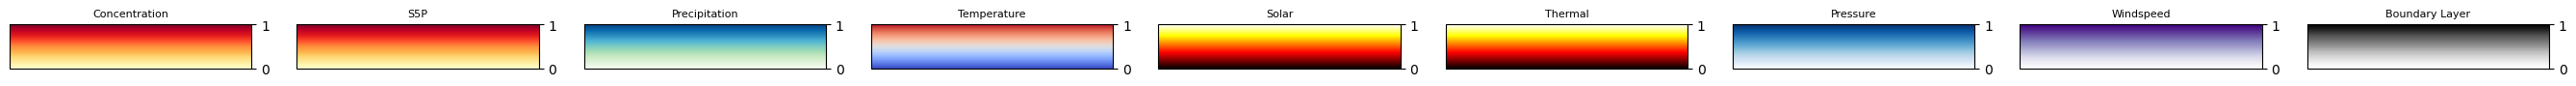

In [26]:
# Styled table with colour gradients per variable group.
summary_viz = summary.loc[:, ~summary.columns.duplicated()].copy()
summary_viz.columns.name = None
summary_viz = summary_viz.round(10)

for col in summary_viz.columns:
    try: summary_viz[col] = pd.to_numeric(summary_viz[col])
    except (ValueError, TypeError): pass

color_map_rules = {
    'Concentration':'YlOrRd', 'S5P':'YlOrRd', 'Precipitation':'GnBu',
    'Temperature':'coolwarm', 'Solar':'hot', 'Thermal':'hot',
    'Pressure':'Blues', 'Windspeed':'Purples', 'Boundary Layer':'Greys',
}

def get_col_scale(series, buffer=0.05):
    vals = pd.to_numeric(series, errors='coerce').dropna()
    if len(vals) == 0: return None, None
    vmin, vmax = vals.min(), vals.max()
    diff = vmax - vmin
    return vmin - diff*buffer, vmax + diff*buffer

scales = {}
for c in summary_viz.select_dtypes(include=['float','int']).columns:
    vmin, vmax = get_col_scale(summary_viz[c])
    if vmin is not None: scales[c] = (vmin, vmax)

styled = summary_viz.style
for col in summary_viz.columns:
    cmap = next((cm for key, cm in color_map_rules.items() if key in col), None)
    if cmap and col in scales:
        vmin, vmax = scales[col]
        styled = styled.background_gradient(subset=[col], cmap=cmap, vmin=vmin, vmax=vmax)

styled = (styled
    .set_properties(**{'text-align':'center','font-family':'Segoe UI, sans-serif',
                       'font-size':'10pt','border':'1px solid #e0e0e0','padding':'4px 8px'})
    .format(precision=6))
display(styled)

legend_data = {}
for key, cmap_name in color_map_rules.items():
    cols = [c for c in summary_viz.columns if key in c and c in scales]
    if cols:
        vmins = [scales[c][0] for c in cols if scales[c][0] is not None]
        vmaxs = [scales[c][1] for c in cols if scales[c][1] is not None]
        if vmins and vmaxs: legend_data[key] = (cmap_name, min(vmins), max(vmaxs))

if legend_data:
    fig, axes = plt.subplots(1, len(legend_data), figsize=(3*len(legend_data), 1))
    if len(legend_data) == 1: axes = [axes]
    for ax, (label, (cmap_name, vmin, vmax)) in zip(axes, legend_data.items()):
        if vmin is not None and vmax is not None and vmin != vmax:
            norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
            mpl.colorbar.ColorbarBase(ax, cmap=mpl.colormaps[cmap_name])  
        ax.set_title(label, fontsize=8)
    plt.tight_layout()
    plt.show()

### Visualisation - cleaned dataset (NaN and negatives removed)

  Cleaning summary:
    NaN rows removed: 0
    Rows removed for negative concentration: 0  (0 negative values)
    Final dataset: 12 rows x 24 columns
    Note: NaN values in the S5P column are expected and normal - Sentinel-5P did not have an image available for that day at that location.


,Date,Region,Station ID,Latitude,Longitude,Pollutant,"Previous Mean (CO, ug/m3)","Current Mean (CO, ug/m3)",S5P Concentration CO (mol/m2),S5P Date,Previous Temperature (C),Current Temperature (C),Previous Pressure (hPa),Current Pressure (hPa),Previous Precipitation (mm),Current Precipitation (mm),Previous Windspeed (m/s),Current Windspeed (m/s),Previous Solar Radiation (kJ/m2),Current Solar Radiation (kJ/m2),Previous Thermal Radiation (kJ/m2),Current Thermal Radiation (kJ/m2),Previous Boundary Layer (km),Current Boundary Layer (km)
0,2024-01-01,EEA,FR05083,49.502730,0.232490,CO,0.165333,0.172250,nan,2024-01-01,9.068853,9.658781,993.605493,994.214831,0.000332,0.000426,8.226832,8.018979,40.530818,366.225088,-158.448940,-167.312940,1.052543,1.086859
1,2024-01-01,EEA,FR05084,49.493330,0.571850,CO,0.195583,0.205500,nan,2024-01-01,8.555023,9.437780,989.108982,989.752720,0.000274,0.000383,6.927167,6.880573,39.880008,350.404650,-140.399744,-161.526503,0.991847,1.066262
2,2024-01-02,EEA,FR05083,49.502730,0.232490,CO,0.136750,0.133250,0.031404,2024-01-02,9.068853,9.658781,993.605493,994.214831,0.000332,0.000426,8.226832,8.018979,40.530818,366.225088,-158.448940,-167.312940,1.052543,1.086859
3,2024-01-02,EEA,FR05084,49.493330,0.571850,CO,0.176800,0.166750,0.028253,2024-01-02,8.555023,9.437780,989.108982,989.752720,0.000274,0.000383,6.927167,6.880573,39.880008,350.404650,-140.399744,-161.526503,0.991847,1.066262
4,2024-01-03,EEA,FR05083,49.502730,0.232490,CO,0.137000,0.141750,0.034140,2024-01-03,9.068853,9.658781,993.605493,994.214831,0.000332,0.000426,8.226832,8.018979,40.530818,366.225088,-158.448940,-167.312940,1.052543,1.086859
5,2024-01-03,EEA,FR05084,49.493330,0.571850,CO,0.180950,0.182250,nan,2024-01-03,8.555023,9.437780,989.108982,989.752720,0.000274,0.000383,6.927167,6.880573,39.880008,350.404650,-140.399744,-161.526503,0.991847,1.066262
6,2024-01-04,EEA,FR05083,49.502730,0.232490,CO,0.143450,0.147000,nan,2024-01-04,9.068853,9.658781,993.605493,994.214831,0.000332,0.000426,8.226832,8.018979,40.530818,366.225088,-158.448940,-167.312940,1.052543,1.086859
7,2024-01-04,EEA,FR05084,49.493330,0.571850,CO,0.183000,0.174750,nan,2024-01-04,8.555023,9.437780,989.108982,989.752720,0.000274,0.000383,6.927167,6.880573,39.880008,350.404650,-140.399744,-161.526503,0.991847,1.066262
8,2024-01-05,EEA,FR05083,49.502730,0.232490,CO,0.161750,0.185750,nan,2024-01-05,9.068853,9.658781,993.605493,994.214831,0.000332,0.000426,8.226832,8.018979,40.530818,366.225088,-158.448940,-167.312940,1.052543,1.086859
9,2024-01-05,EEA,FR05084,49.493330,0.571850,CO,0.176700,0.182500,0.030434,2024-01-05,8.555023,9.437780,989.108982,989.752720,0.000274,0.000383,6.927167,6.880573,39.880008,350.404650,-140.399744,-161.526503,0.991847,1.066262


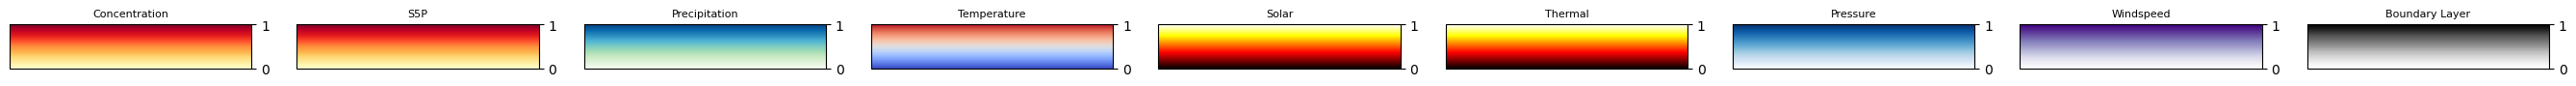

In [32]:
import numpy as np

summary_clean = summary.loc[:, ~summary.columns.duplicated()].copy()
summary_clean.columns.name = None
summary_clean = summary_clean.replace(['None','none','NaN','nan',''], np.nan).round(10)

for col in summary_clean.columns:
    try: summary_clean[col] = pd.to_numeric(summary_clean[col])
    except (ValueError, TypeError): pass

n_before = len(summary_clean)
summary_clean = summary_clean.dropna(how='all').reset_index(drop=True)
n_nan_removed = n_before - len(summary_clean)

conc_cols = [c for c in summary_clean.columns if 'Concentration' in c or 'Mean' in c]
n_before2 = len(summary_clean)
if conc_cols:
    mask_neg = (summary_clean[conc_cols] < 0).any(axis=1)
    n_neg    = int(mask_neg.sum())
    summary_clean = summary_clean[~mask_neg].reset_index(drop=True)
else:
    n_neg = 0
n_neg_removed = n_before2 - len(summary_clean)

print(f'  Cleaning summary:')
print(f'    NaN rows removed: {n_nan_removed:,}')
print(f'    Rows removed for negative concentration: {n_neg_removed:,}  ({n_neg} negative values)')
print(f'    Final dataset: {len(summary_clean):,} rows x {len(summary_clean.columns)} columns')
print(f'    Note: NaN values in the S5P column are expected and normal - Sentinel-5P did not have an image available for that day at that location.')

color_map_rules = {
    'Concentration':'YlOrRd','S5P':'YlOrRd','Precipitation':'GnBu',
    'Temperature':'coolwarm','Solar':'hot','Thermal':'hot',
    'Pressure':'Blues','Windspeed':'Purples','Boundary Layer':'Greys',
}

scales_c = {}
for c in summary_clean.select_dtypes(include=['float','int']).columns:
    vals = pd.to_numeric(summary_clean[c], errors='coerce').dropna()
    if len(vals):
        vmin, vmax = vals.min(), vals.max()
        diff = vmax - vmin
        scales_c[c] = (vmin - diff*0.05, vmax + diff*0.05)

styled_c = summary_clean.style
for col in summary_clean.columns:
    cmap = next((cm for key, cm in color_map_rules.items() if key in col), None)
    if cmap and col in scales_c:
        vmin, vmax = scales_c[col]
        styled_c = styled_c.background_gradient(subset=[col], cmap=cmap, vmin=vmin, vmax=vmax)

styled_c = (styled_c
    .set_properties(**{'text-align':'center','font-family':'Segoe UI, sans-serif',
                       'font-size':'10pt','border':'1px solid #e0e0e0','padding':'4px 8px'})
    .format(precision=6))
display(styled_c)

legend_c = {}
for key, cmap_name in color_map_rules.items():
    cols = [c for c in summary_clean.columns if key in c]
    if cols:
        # Only consider numeric columns to avoid type errors
        num_vals = pd.to_numeric(
            summary_clean[cols].stack(), errors='coerce'
        ).dropna()
        if len(num_vals) == 0:
            continue
        vmin = float(num_vals.min())
        vmax = float(num_vals.max())
        if pd.notna(vmin) and pd.notna(vmax) and vmin != vmax:
            legend_c[key] = (cmap_name, vmin, vmax)

if legend_c:
    fig, axes = plt.subplots(1, len(legend_c), figsize=(3*len(legend_c), 1))
    if len(legend_c) == 1: axes = [axes]
    for ax, (label, (cmap_name, vmin, vmax)) in zip(axes, legend_c.items()):
        if pd.notna(vmin) and pd.notna(vmax) and vmin != vmax:
            norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
            mpl.colorbar.ColorbarBase(ax, cmap=mpl.colormaps[cmap_name])  
        ax.set_title(label, fontsize=8)
    plt.tight_layout()
    plt.show()

## Step 12 - Export Results

In [ ]:
# Save the final cleaned dataset to a timestamped CSV.
W = 56

start_str  = pd.to_datetime(cfg['start_date']).strftime('%Y%m%d')
end_str    = pd.to_datetime(cfg['end_date']).strftime('%Y%m%d')
output_dir = f'results/EEA_ERA5_S5P_{start_str}_to_{end_str}'
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(output_dir, 'summary_clean.csv')
summary_clean.to_csv(output_path, index=False)

print('_' * W)
print('  Export complete')
print('-' * W)
print(f'  Rows exported  : {len(summary_clean):,}')
print(f'  Columns        : {len(summary_clean.columns)}')
print(f'  Saved to       : {output_path}')
print('_' * W)